'synthetic_learning_roadmap.csv' dataset loaded successfully!

--- Preprocessing the Data ---
Data preprocessing complete.

--- Training the Random Forest Model ---
Model training complete.

--- Evaluating the Model ---
Model Accuracy: 100.00%

Classification Report:
                                    precision    recall  f1-score   support

       Explore Expert-Level Topics       1.00      1.00      1.00        18
       Read Advanced Documentation       1.00      1.00      1.00        15
          Review Advanced Concepts       1.00      1.00      1.00         3
          Review Beginner Concepts       1.00      1.00      1.00        10
      Review Intermediate Concepts       1.00      1.00      1.00         7
            Start Advanced Project       1.00      1.00      1.00         8
        Start Intermediate Project       1.00      1.00      1.00        13
Watch Intermediate Video Tutorials       1.00      1.00      1.00        26

                          accuracy            

C:\Users\siddh\AppData\Local\Temp\ipykernel_19828\1409082153.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


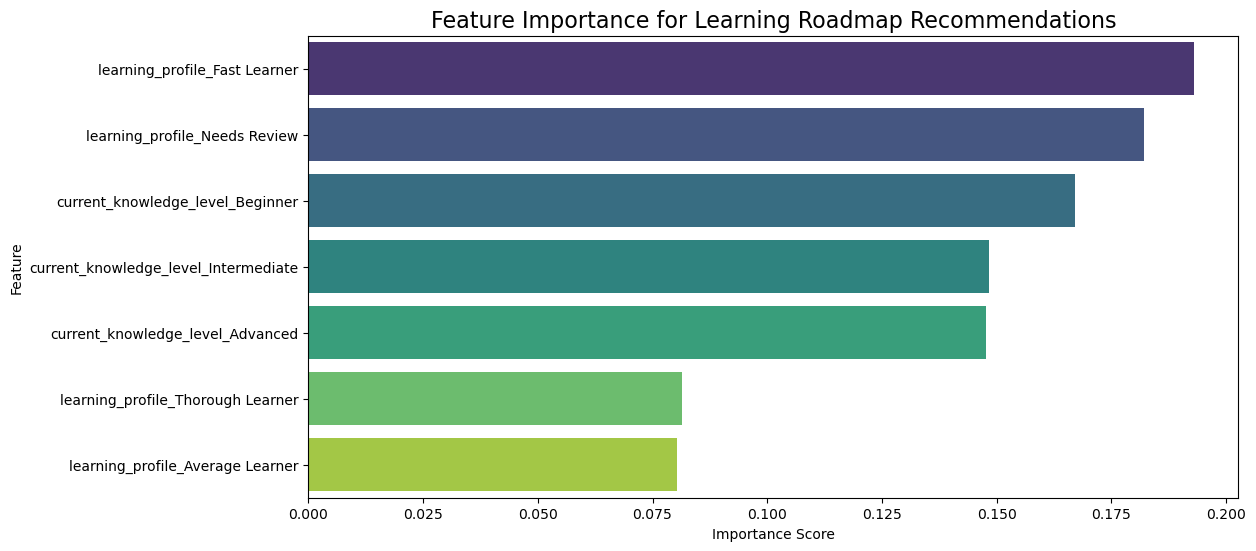

The plot above shows which factors most influence the model's recommendations.

--- Saving the final model and encoders ---
All artifacts for the final model saved successfully in: ../Models/Learning_Roadmap


In [1]:
# ---------------------------------
# 1. IMPORTING LIBRARIES
# ---------------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ---------------------------------
# 2. LOADING THE DATASET
# ---------------------------------
try:
    df = pd.read_csv('../Datasets/Learning_Roadmap/synthetic_learning_roadmap.csv')
    print("'synthetic_learning_roadmap.csv' dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'synthetic_learning_roadmap.csv' not found. Please ensure the data generation script was run.")
    exit()

# ---------------------------------
# 3. DATA PREPROCESSING
# ---------------------------------
print("\n--- Preprocessing the Data ---")

# Define features (X) and target (y)
features = ['current_knowledge_level', 'learning_profile']
target = 'recommended_next_step'

X = df[features]
y = df[target]

# Encode the categorical features using OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_processed = ohe.fit_transform(X)

# Encode the target variable
le = LabelEncoder()
y_processed = le.fit_transform(y)

# Get feature names for later use (e.g., in feature importance plot)
feature_names = ohe.get_feature_names_out()

print("Data preprocessing complete.")


# ---------------------------------
# 4. MODEL TRAINING
# ---------------------------------
print("\n--- Training the Random Forest Model ---")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed)

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

print("Model training complete.")

# ---------------------------------
# 5. MODEL EVALUATION
# ---------------------------------
print("\n--- Evaluating the Model ---")

y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


# ---------------------------------
# 6. FEATURE IMPORTANCE
# ---------------------------------
print("\n--- Analyzing Feature Importance ---")

# Get feature importances from the trained model
importances = rf_classifier.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Learning Roadmap Recommendations', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print("The plot above shows which factors most influence the model's recommendations.")


# ---------------------------------
# 7. SAVING THE ARTIFACTS
# ---------------------------------
print("\n--- Saving the final model and encoders ---")

model_dir = '../Models/Learning_Roadmap'
os.makedirs(model_dir, exist_ok=True)

# Define file paths
model_path = os.path.join(model_dir, 'model.joblib')
ohe_path = os.path.join(model_dir, 'one_hot_encoder.joblib')
le_path = os.path.join(model_dir, 'label_encoder.joblib')

# Save the artifacts
joblib.dump(rf_classifier, model_path)
joblib.dump(ohe, ohe_path)
joblib.dump(le, le_path)

print(f"All artifacts for the final model saved successfully in: {model_dir}")